In [2]:
# Imports and Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from umap import UMAP
from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
np.random.seed(42)

In [3]:
# 1. Dataset Loading (using optdigits/digits dataset)
print("Loading Digits Dataset...")
digits = load_digits()
X = digits.data
y_true = digits.target

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset shape: {X_scaled.shape}")
print(f"Number of true classes (k): {len(np.unique(y_true))}")

Loading Digits Dataset...
Dataset shape: (1797, 64)
Number of true classes (k): 10


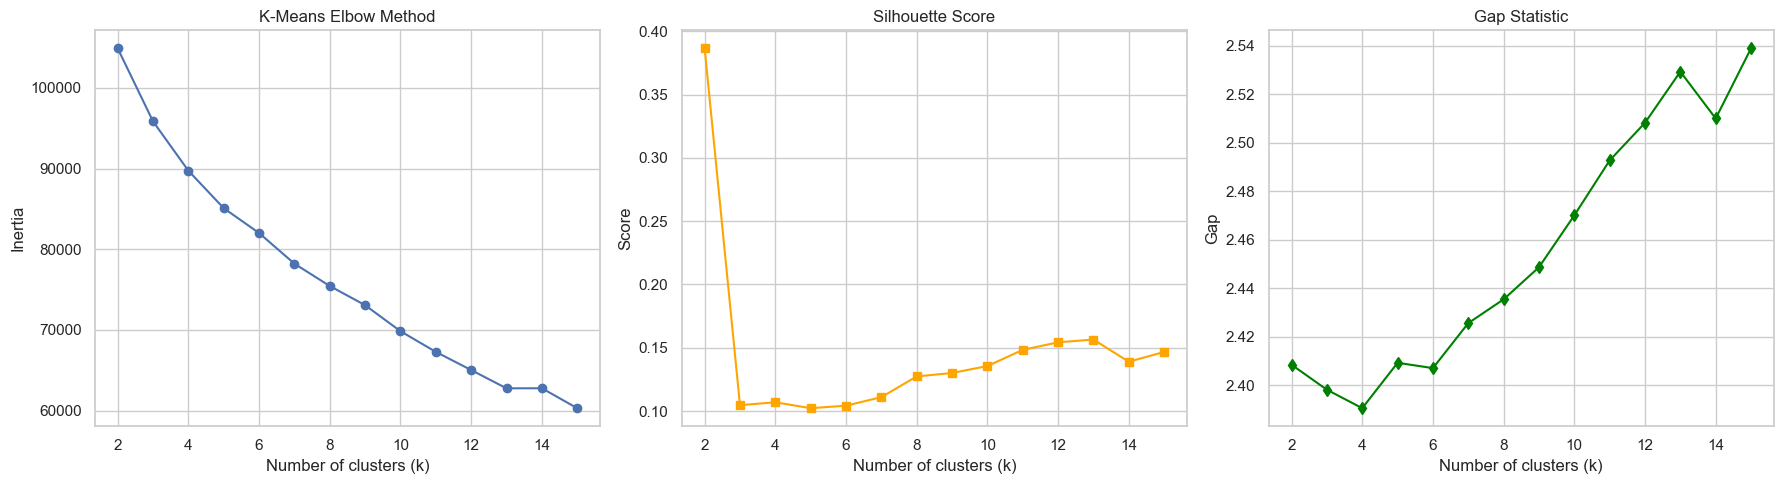

In [4]:
# 2. Model Selection: K-Means (Elbow, Silhouette, Gap Statistic)
k_range = range(2, 16)
inertia = []
sil_scores = []
gap_stats = []

# Gap Statistic Helper Function
def compute_gap(X, k, n_refs=3):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    disp_orig = km.inertia_
    
    # Generate reference datasets
    disp_refs = []
    for _ in range(n_refs):
        random_data = np.random.uniform(np.min(X, axis=0), np.max(X, axis=0), size=X.shape)
        km_ref = KMeans(n_clusters=k, random_state=42)
        km_ref.fit(random_data)
        disp_refs.append(km_ref.inertia_)
    
    # Gap calculation
    gap = np.mean(np.log(disp_refs)) - np.log(disp_orig)
    return gap

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    gap_stats.append(compute_gap(X_scaled, k))

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('K-Means Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')

plt.subplot(1, 3, 2)
plt.plot(k_range, sil_scores, marker='s', color='orange')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Score')

plt.subplot(1, 3, 3)
plt.plot(k_range, gap_stats, marker='d', color='green')
plt.title('Gap Statistic')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Gap')

plt.tight_layout()
plt.show()

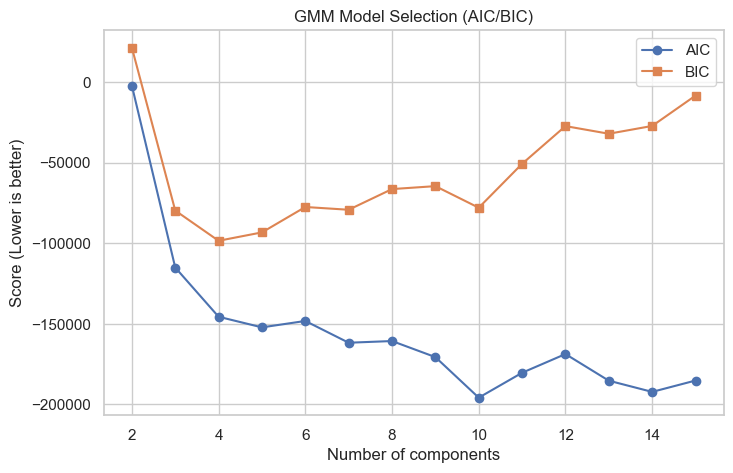

In [5]:
# 3. Model Selection: GMM (AIC / BIC)
aic_scores = []
bic_scores = []

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type='full', n_init=3)
    gmm.fit(X_scaled)
    aic_scores.append(gmm.aic(X_scaled))
    bic_scores.append(gmm.bic(X_scaled))

plt.figure(figsize=(8, 5))
plt.plot(k_range, aic_scores, label='AIC', marker='o')
plt.plot(k_range, bic_scores, label='BIC', marker='s')
plt.title('GMM Model Selection (AIC/BIC)')
plt.xlabel('Number of components')
plt.ylabel('Score (Lower is better)')
plt.legend()
plt.show()

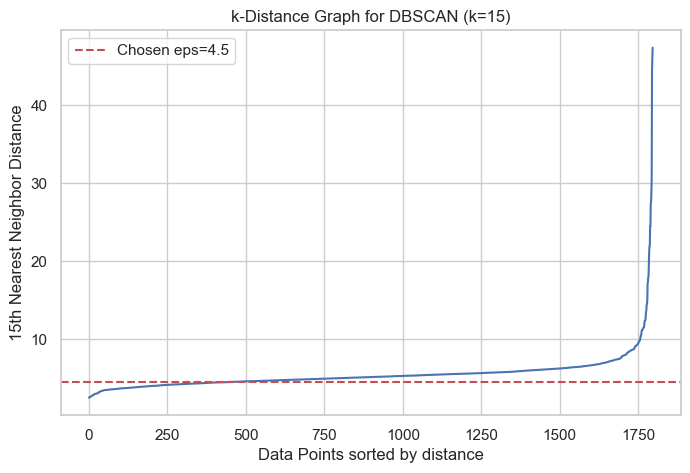

In [6]:
# 4. Model Selection: DBSCAN (k-distance graph)
# Rule of thumb for min_samples = 2 * dimensions, but for 64 dims, that's 128 (might be too strict limit for N=1797).
# Let's use min_samples = 15
min_samples = 15
nearest_neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors = nearest_neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)

# Sort distances
distances = np.sort(distances[:, min_samples-1], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title('k-Distance Graph for DBSCAN (k=15)')
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'{min_samples}th Nearest Neighbor Distance')
plt.axhline(y=4.5, color='r', linestyle='--', label='Chosen eps=4.5')
plt.legend()
plt.show()

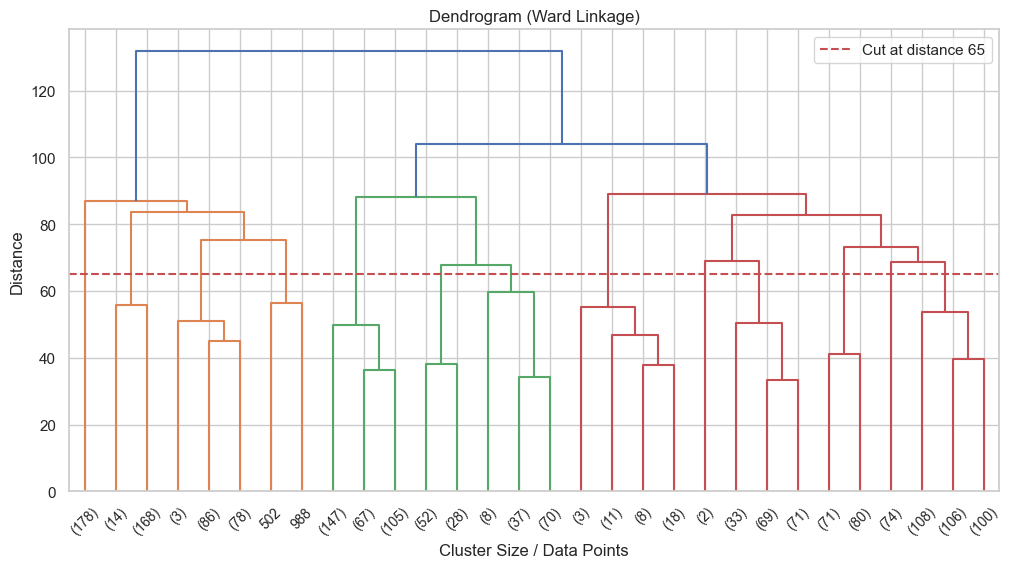

In [7]:
# 5. Model Selection: Agglomerative Clustering (Dendrogram)
plt.figure(figsize=(12, 6))
plt.title("Dendrogram (Ward Linkage)")
# Compute linkage matrix
Z = linkage(X_scaled, method='ward')
dendrogram(Z, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.xlabel("Cluster Size / Data Points")
plt.ylabel("Distance")
plt.axhline(y=65, color='r', linestyle='--', label='Cut at distance 65')
plt.legend()
plt.show()

In [8]:
# 6. Evaluation of The Four Algorithms (Internal & External Metrics)
# Based on selections: 10 target classes (digits 0-9)
optimal_k = 10

km_labels = KMeans(n_clusters=optimal_k, random_state=42).fit_predict(X_scaled)
gmm_labels = GaussianMixture(n_components=optimal_k, random_state=42).fit_predict(X_scaled)
dbscan_labels = DBSCAN(eps=4.5, min_samples=15).fit_predict(X_scaled)
agg_labels = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward').fit_predict(X_scaled)

models = {
    "K-Means": km_labels,
    "GMM": gmm_labels,
    "DBSCAN": dbscan_labels,
    "Agglomerative": agg_labels
}

metrics_list = []
for name, labels in models.items():
    # Only evaluate internal metrics if more than 1 cluster is found (DBSCAN might find 1 or pure noise if poorly tuned)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    if n_clusters > 1:
        sil = silhouette_score(X_scaled, labels)
        ch_score = calinski_harabasz_score(X_scaled, labels)
        db_score = davies_bouldin_score(X_scaled, labels)
    else:
        sil, ch_score, db_score = np.nan, np.nan, np.nan
        
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    fmi = fowlkes_mallows_score(y_true, labels)
    
    metrics_list.append({
        "Algorithm": name,
        "Clusters Found": n_clusters,
        "Silhouette": sil,
        "Calinski-Harabasz": ch_score,
        "Davies-Bouldin": db_score,
        "ARI": ari,
        "NMI": nmi,
        "FMI": fmi
    })

eval_df = pd.DataFrame(metrics_list)
display(eval_df)

,Algorithm,Clusters Found,Silhouette,Calinski-Harabasz,Davies-Bouldin,ARI,NMI,FMI
0,K-Means,10,0.135582,113.060448,1.806079,0.530512,0.672025,0.591863
1,GMM,10,0.117905,102.577554,2.002885,0.546745,0.690155,0.605524
2,DBSCAN,9,-0.004938,52.781325,2.513683,0.238756,0.570333,0.385154
3,Agglomerative,10,0.125325,105.825164,1.967178,0.664346,0.795587,0.711078


In [9]:
# 7. Cluster Stability Analysis (Bootstrap Subsampling)
def cluster_stability_analysis(model_class, model_kwargs, X, n_iterations=30, subsample_fraction=0.8):
    n_samples = X.shape[0]
    subsample_size = int(n_samples * subsample_fraction)
    
    ari_scores = []
    
    # Fit base model on full data
    base_model = model_class(**model_kwargs)
    base_labels = base_model.fit_predict(X)
    
    for _ in range(n_iterations):
        # Bootstrap subsampling indices
        indices = np.random.choice(n_samples, size=subsample_size, replace=False)
        X_sub = X[indices]
        
        # Fit on subsample
        sub_model = model_class(**model_kwargs)
        sub_labels = sub_model.fit_predict(X_sub)
        
        # Compare with the original assignments for the subsampled points
        score = adjusted_rand_score(base_labels[indices], sub_labels)
        ari_scores.append(score)
        
    return np.mean(ari_scores), np.std(ari_scores)

print("Cluster Stability (Subsample similarity via ARI - 30 Iterations):")
km_stab_idx = cluster_stability_analysis(KMeans, {'n_clusters': optimal_k, 'random_state': 42}, X_scaled)
print(f"K-Means Stability: {km_stab_idx[0]:.4f} ± {km_stab_idx[1]:.4f}")

gmm_stab_idx = cluster_stability_analysis(GaussianMixture, {'n_components': optimal_k, 'random_state': 42}, X_scaled)
print(f"GMM Stability:     {gmm_stab_idx[0]:.4f} ± {gmm_stab_idx[1]:.4f}")

agg_stab_idx = cluster_stability_analysis(AgglomerativeClustering, {'n_clusters': optimal_k, 'linkage': 'ward'}, X_scaled)
print(f"Agglom. Stability: {agg_stab_idx[0]:.4f} ± {agg_stab_idx[1]:.4f}")

dbscan_stab_idx = cluster_stability_analysis(DBSCAN, {'eps': 4.5, 'min_samples': 15}, X_scaled)
print(f"DBSCAN Stability:  {dbscan_stab_idx[0]:.4f} ± {dbscan_stab_idx[1]:.4f}")

Cluster Stability (Subsample similarity via ARI - 30 Iterations):
K-Means Stability: 0.7446 ± 0.0800
GMM Stability:     0.6051 ± 0.1020
Agglom. Stability: 0.6965 ± 0.1090
DBSCAN Stability:  0.7457 ± 0.0371


In [10]:
# 8. Cluster Ensemble (Co-association Matrix)
# Get labels from various models (KMeans for varying k, GMM, DBSCAN)
km1 = KMeans(n_clusters=8, random_state=42).fit_predict(X_scaled)
km2 = KMeans(n_clusters=10, random_state=42).fit_predict(X_scaled)
km3 = KMeans(n_clusters=12, random_state=42).fit_predict(X_scaled)
gmm_ens = GaussianMixture(n_components=10, random_state=42).fit_predict(X_scaled)
db_ens = DBSCAN(eps=4.5, min_samples=15).fit_predict(X_scaled)

ensemble_labels = np.array([km1, km2, km3, gmm_ens, db_ens])
n_samples = X_scaled.shape[0]

# Build co-association matrix
co_assoc_matrix = np.zeros((n_samples, n_samples))
for labels in ensemble_labels:
    for i in range(len(np.unique(labels))):
        # Find points in this cluster
        indices = np.where(labels == i)[0]
        # Add 1 to intersections
        for row in indices:
            co_assoc_matrix[row, indices] += 1

# Normalize
co_assoc_matrix /= len(ensemble_labels)

# Convert similarity to distance matrix: distance = 1 - similarity
distance_matrix = 1.0 - co_assoc_matrix

# Use Agglomerative Clustering on the distance matrix to form consensus
consensus_clustering = AgglomerativeClustering(n_clusters=optimal_k, metric='precomputed', linkage='average')
consensus_labels = consensus_clustering.fit_predict(distance_matrix)

cons_ari = adjusted_rand_score(y_true, consensus_labels)
cons_nmi = normalized_mutual_info_score(y_true, consensus_labels)

print("Ensemble Clustering vs Individual (for k=10) Performance:")
print(f"K-Means (k=10) ARI: {adjusted_rand_score(y_true, km_labels):.4f} | NMI: {normalized_mutual_info_score(y_true, km_labels):.4f}")
print(f"GMM (k=10)     ARI: {adjusted_rand_score(y_true, gmm_labels):.4f} | NMI: {normalized_mutual_info_score(y_true, gmm_labels):.4f}")
print(f"Ensemble       ARI: {cons_ari:.4f} | NMI: {cons_nmi:.4f}")

Ensemble Clustering vs Individual (for k=10) Performance:
K-Means (k=10) ARI: 0.5305 | NMI: 0.6720
GMM (k=10)     ARI: 0.5467 | NMI: 0.6902
Ensemble       ARI: 0.5374 | NMI: 0.6739


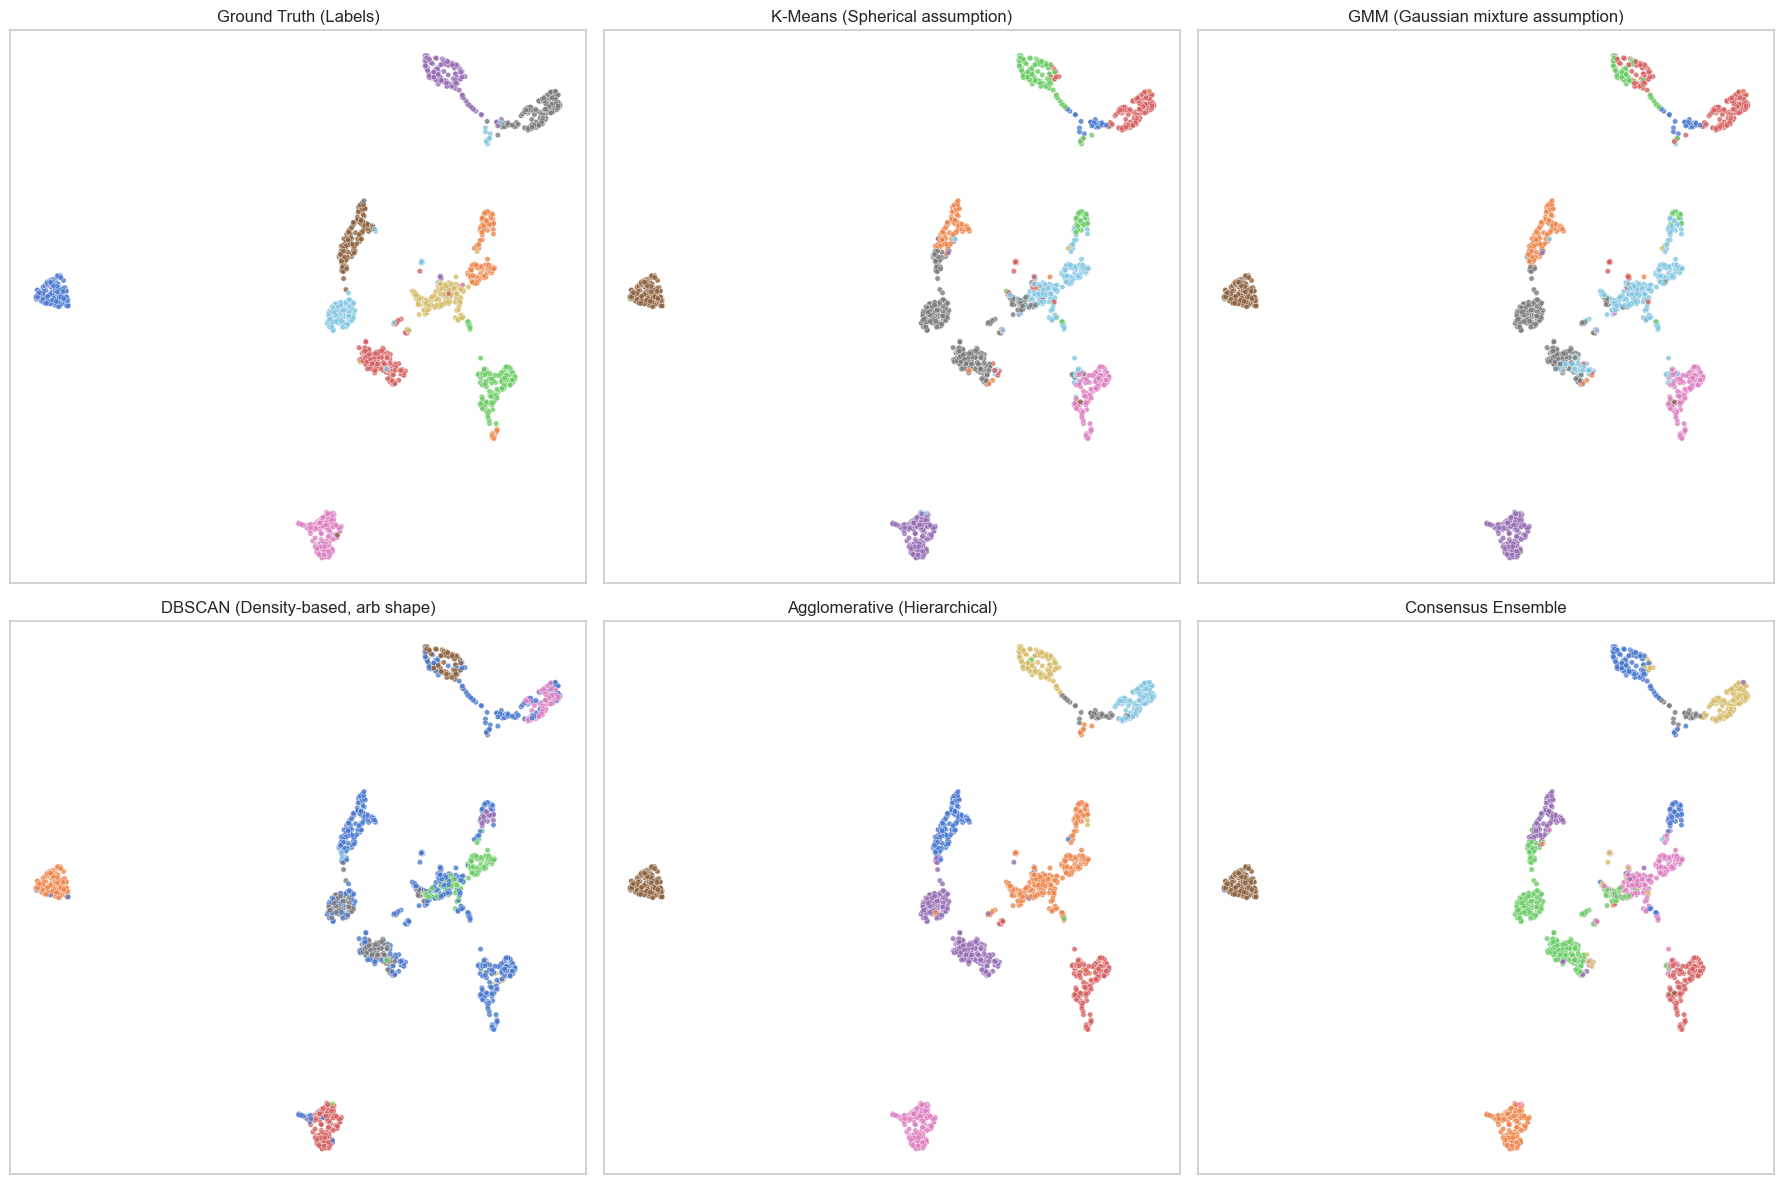

In [11]:
# 9. Visualization using UMAP (highlighting cluster shapes)
# Dimensionality reduction to 2D for visualization
reducer = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_2d = reducer.fit_transform(X_scaled)

methods = {
    'Ground Truth (Labels)': y_true,
    'K-Means (Spherical assumption)': km_labels,
    'GMM (Gaussian mixture assumption)': gmm_labels,
    'DBSCAN (Density-based, arb shape)': dbscan_labels,
    'Agglomerative (Hierarchical)': agg_labels,
    'Consensus Ensemble': consensus_labels
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# Adjust colormap bounds
for i, (title, labels) in enumerate(methods.items()):
    ax = axes[i]
    n_clusters = len(np.unique(labels))
    palette = sns.color_palette("muted", n_clusters)
    
    sns.scatterplot(
        x=X_2d[:, 0], y=X_2d[:, 1],
        hue=labels,
        palette=palette,
        legend=False,
        s=15,
        alpha=0.8,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Discussion: Assumptions of Each Algorithm and Violations

**1. K-Means:**
*   **Assumptions:** Assumes clusters are spherical, have equal variance (isotropic), and roughly equal size. It minimizes variance within clusters.
*   **Violation Effects:** When data contains elongated (elliptical) clusters, varying densities, or nested structures (e.g., moongraphs), K-Means aggressively splits these natural groups to forcefully maintain spherical boundaries, dropping stability.

**2. Gaussian Mixture Model (GMM):**
*   **Assumptions:** Assumes data points are generated from a mixture of a finite number of Gaussian distributions (can be elliptical when covariance is `full`).
*   **Violation Effects:** Much more flexible than K-Means, but if clusters are strictly non-Gaussian (e.g., uniform square blocks, extreme outliers or heavy-tailed distributions), GMM will either attempt to fit multiple Gaussians to one cluster or fail to capture the true underlying distribution, heavily impacted by noise.

**3. DBSCAN:**
*   **Assumptions:** Assumes continuous areas of high density (clusters) are separated by areas of low density (noise). Does not assume any geometry, thus models arbitrary shapes.
*   **Violation Effects:** Fails or drops drastically in performance if the dataset contains clusters with varying overlapping densities. Setting a single global `eps` and `min_samples` is impossible if one cluster is dense and another is sparse. In our digit evaluation, high dimensionality often spreads data out, requiring careful k-distance tuning, often resulting in either all points being noise or merged into a single mega-cluster.

**4. Agglomerative Clustering (Ward Linkage):**
*   **Assumptions:** Assumes a hierarchical structure. Using Ward linkage, it implies spherical distribution since it minimizes intra-cluster variance, functionally similar to K-Means' variance assumption at each step.
*   **Violation Effects:** Sensitive to noise and outliers. Using alternative linkages (like Single or Complete) can allow arbitrary shapes but suffer severely from "chaining" (creating long unnatural string-like clusters containing distinct segments).